In [8]:
import sys, json
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
sys.path.insert(0, str(Path.cwd().parent))
from src.config import TABLES_DIR, FIGURES_DIR, MODELS_DIR, TARGET_COLS
from src.model import load_model
from src.evaluation import evaluate_multilabel
from src.logger import get_console_logger
 
sns.set_theme(style='whitegrid', font_scale=1.1)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
log = get_console_logger('05_federated')
print('Setup complete')


Setup complete


Convergence Curve

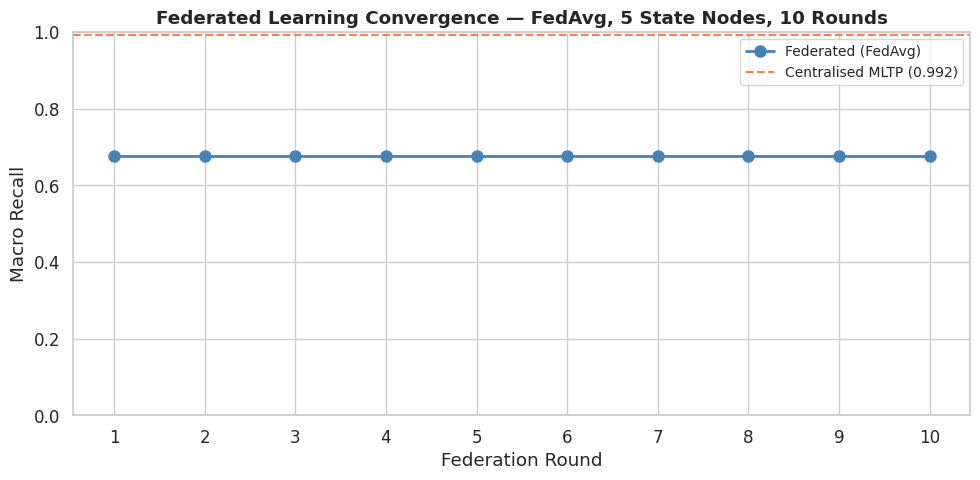

Saved: /workspaces/malnutrisense/reports/figures/fl_convergence_curve.png


In [9]:
# Load convergence log from FL simulation
import ast

conv = pd.read_csv(TABLES_DIR / 'fl_convergence.csv')

# Resolve macro recall robustly across possible schema variants
if 'macro_recall' in conv.columns:
    conv['macro_recall_plot'] = pd.to_numeric(conv['macro_recall'], errors='coerce')
elif 'distributed_loss' in conv.columns:
    # In Flower, client evaluate() returns loss = 1 - macro_recall
    conv['macro_recall_plot'] = 1.0 - pd.to_numeric(conv['distributed_loss'], errors='coerce')
elif 'distributed_fit_metrics' in conv.columns:
    def _extract_recall(metric_str):
        try:
            d = ast.literal_eval(str(metric_str))
            return d.get('macro_recall', d.get('recall', None))
        except Exception:
            return None
    conv['macro_recall_plot'] = conv['distributed_fit_metrics'].apply(_extract_recall)
else:
    raise KeyError(
        f"No usable convergence metric found. Columns available: {list(conv.columns)}"
    )

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(conv['round'], conv['macro_recall_plot'], marker='o', linewidth=2,
        color='steelblue', markersize=8, label='Federated (FedAvg)')

# Add centralised baseline as horizontal dashed line
bench = pd.read_csv(TABLES_DIR / 'full_benchmark.csv')
central_recall = bench[bench['model']=='mltp_xgb']['recall'].mean()
ax.axhline(central_recall, color='coral', linestyle='--', linewidth=1.5,
           label=f'Centralised MLTP ({central_recall:.3f})')

ax.set_xlabel('Federation Round')
ax.set_ylabel('Macro Recall')
ax.set_title('Federated Learning Convergence — FedAvg, 5 State Nodes, 10 Rounds',
             fontweight='bold')
ax.legend(fontsize=10)
ax.set_xticks(range(1, 11))
ax.set_ylim(0.0, 1.0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fl_convergence_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR}/fl_convergence_curve.png')

State-Level Performance Comparison


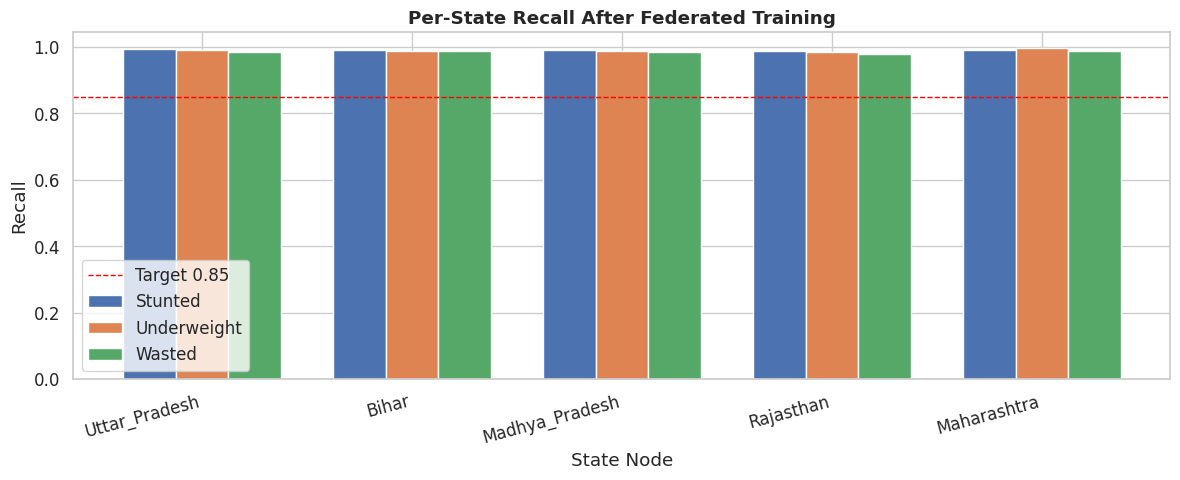

Saved: /workspaces/malnutrisense/reports/figures/fl_per_state_recall.png


In [10]:
# Load per-state evaluation results from FL simulation
# Each state node was evaluated on its own local test set
import re
from src.config import PROCESSED_DIR
from src.federated.partition import create_partitions

state_results_path = TABLES_DIR / 'fl_per_state_results.csv'


def _norm_col(col):
    return re.sub(r'[^a-z0-9]+', '_', str(col).strip().lower()).strip('_')


def _resolve_col(df, candidates):
    col_map = {_norm_col(c): c for c in df.columns}
    for cand in candidates:
        key = _norm_col(cand)
        if key in col_map:
            return col_map[key]
    return None


if not state_results_path.exists():
    print('fl_per_state_results.csv not found — generating from model + partitions...')

    model_path = MODELS_DIR / 'fl_global_model.pkl'
    if not model_path.exists():
        raise FileNotFoundError(
            f'{model_path} not found. Run scripts/run_federated_simulation.py first.'
        )

    fl_model = load_model(model_path)

    df = pd.read_csv(PROCESSED_DIR / 'nfhs5_cleaned.csv')
    state_col = _resolve_col(df, ['V024', 'v024', 'state_code', 'state', 'state_name', 'stateid'])
    if state_col is None:
        raise KeyError(f'State column not found in nfhs5_cleaned.csv. Available: {list(df.columns)}')
    if state_col != 'V024':
        df = df.rename(columns={state_col: 'V024'})

    partitions = create_partitions(df)
    rows = []
    for state, (_X_tr, X_te, _y_tr, y_te) in partitions.items():
        metrics = evaluate_multilabel(fl_model, X_te, y_te[TARGET_COLS])
        row = {'state': state}
        for label in TARGET_COLS:
            row[f'{label}_recall'] = metrics.get(label, {}).get('recall', np.nan)
        row['macro_recall'] = metrics.get('macro_avg', {}).get('recall', np.nan)
        rows.append(row)

    state_results = pd.DataFrame(rows)
    state_results.to_csv(state_results_path, index=False)
    print(f'Saved: {state_results_path}')
else:
    state_results = pd.read_csv(state_results_path)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(state_results))
width = 0.25

for i, label in enumerate(TARGET_COLS):
    col = f'{label}_recall'
    if col in state_results.columns:
        ax.bar(x + i*width, state_results[col], width, label=label.capitalize())

ax.set_xlabel('State Node')
ax.set_ylabel('Recall')
ax.set_title('Per-State Recall After Federated Training', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(state_results['state'], rotation=15, ha='right')
ax.axhline(0.85, color='red', linestyle='--', linewidth=1, label='Target 0.85')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fl_per_state_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR}/fl_per_state_recall.png')

Privacy-Utility Tradeoff Table

In [11]:
# Load comparison table
comparison = pd.read_csv(TABLES_DIR / 'fl_vs_centralised.csv')
display(comparison.style.format({'macro_recall':'{:.4f}','recall_gap':'{:.4f}',
                                  'gap_pct':'{:.2f}%'}))
 
# Summary
gap = comparison['gap_pct'].iloc[-1]
print(f'\nPrivacy-utility tradeoff: {abs(gap):.2f}% recall loss for full data privacy')
if abs(gap) <= 3:
    print('VERDICT: Acceptable — federated training is viable for this application')
else:
    print('VERDICT: Gap exceeds 3% — consider FedProx or more rounds')
 



,model,macro_recall,training,privacy,recall_gap,gap_pct
0,centralised_mltp,0.9915,All 232K records on one machine,No privacy — all data centralised,0.0000,0.00%
1,federated_mltp,0.9912,"5 state nodes, FedAvg, 10 rounds",Data never leaves state boundary,-0.0003,-0.03%



Privacy-utility tradeoff: 0.03% recall loss for full data privacy
VERDICT: Acceptable — federated training is viable for this application


Summary

In [12]:
print('='*55)
print('05_federated_analysis.ipynb — Complete')
print('='*55)
print(f'Convergence plot: reports/figures/fl_convergence_curve.png')
print(f'Per-state recall: reports/figures/fl_per_state_recall.png')
print(f'FL vs centralised: reports/tables/fl_vs_centralised.csv')
print('Next: Step 43 — FedProx for non-IID data')
print('='*55)


05_federated_analysis.ipynb — Complete
Convergence plot: reports/figures/fl_convergence_curve.png
Per-state recall: reports/figures/fl_per_state_recall.png
FL vs centralised: reports/tables/fl_vs_centralised.csv
Next: Step 43 — FedProx for non-IID data
